In [18]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [19]:
# Cell 2 — Load and inspect dataset
df = pd.read_csv('../data/dataset.csv')

print("Shape:", df.shape)
print("\nSamples per letter:")
print(df['label'].value_counts().sort_index())

Shape: (9600, 64)

Samples per letter:
label
A    400
B    400
C    400
D    400
E    400
F    400
G    400
H    400
I    400
K    400
L    400
M    400
N    400
O    400
P    400
Q    400
R    400
S    400
T    400
U    400
V    400
W    400
X    400
Y    400
Name: count, dtype: int64


In [20]:
# Cell 3 — Separate features and labels
X = df.drop(columns=['label']).values  # shape: (9600, 63)
y = df['label'].values                 # shape: (9600,)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sample y values:", y[:5])

X shape: (9600, 63)
y shape: (9600,)
Sample y values: <StringArray>
['A', 'A', 'A', 'A', 'A']
Length: 5, dtype: str


In [21]:
# Cell 4 — Wrist normalization
# Subtract wrist (landmark 0) x and y from all landmarks
# Z is kept as-is — it already represents depth relative to the wrist

X_normalized = X.copy().reshape(-1, 21, 3)  # reshape to (9600, 21, 3) for easier indexing

wrist_x = X_normalized[:, 0, 0]  # shape (9600,)
wrist_y = X_normalized[:, 0, 1]

X_normalized[:, :, 0] -= wrist_x[:, np.newaxis]  # subtract from all 21 x values
X_normalized[:, :, 1] -= wrist_y[:, np.newaxis]  # subtract from all 21 y values

X_normalized = X_normalized.reshape(-1, 63)  # flatten back to (9600, 63)

print("Wrist x after normalization (should all be 0.0):", X_normalized[:5, 0])
print("Wrist y after normalization (should all be 0.0):", X_normalized[:5, 1])

Wrist x after normalization (should all be 0.0): [0. 0. 0. 0. 0.]
Wrist y after normalization (should all be 0.0): [0. 0. 0. 0. 0.]


In [22]:
# Cell 5 — Scale normalization
# Divide each sample by its own max absolute value
# This makes hand size and distance irrelevant — only shape matters

max_vals = np.max(np.abs(X_normalized), axis=1, keepdims=True)  # shape: (9600, 1)
X_normalized = X_normalized / max_vals

print("Min value in dataset:", X_normalized.min())
print("Max value in dataset:", X_normalized.max())
print("Sample row (first 9 values):", X_normalized[0, :9].round(4))

Min value in dataset: -1.0
Max value in dataset: 1.0
Sample row (first 9 values): [ 0.      0.     -0.      0.295  -0.1103 -0.0937  0.5287 -0.4133 -0.1145]


In [23]:
# Cell 6 — Label encoding and train/val split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Convert letter strings to integers (A=0, B=1, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # e.g. 'A' -> 0, 'B' -> 1

# Convert integers to one-hot vectors for categorical_crossentropy
y_onehot = keras.utils.to_categorical(y_encoded, num_classes=24)

# 80/20 split, stratified so each letter is equally represented in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X_normalized, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("Classes:", list(le.classes_))

X_train: (7680, 63)
X_val:   (1920, 63)
y_train: (7680, 24)
y_val:   (1920, 24)
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


In [24]:
# Cell 7 — Build the model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(63,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(24, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 128)               8192      
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 24)                1560      
                                                                 
Total params: 18008 (70.34 KB)
Trainable params: 18008 (70.34 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [25]:
# Cell 8 — Train the model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='../model/fsl_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

print("\nBest validation accuracy:", max(history.history['val_accuracy']))

Epoch 1/100
233/240 [============================>.] - ETA: 0s - loss: 2.0782 - accuracy: 0.3620

d:\fsl-classifier\venv\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


240/240 [==============================] - 2s 4ms/step - loss: 2.0524 - accuracy: 0.3688 - val_loss: 0.8911 - val_accuracy: 0.8297
Epoch 2/100
240/240 [==============================] - 1s 4ms/step - loss: 0.8451 - accuracy: 0.6999 - val_loss: 0.3632 - val_accuracy: 0.9484
Epoch 3/100
240/240 [==============================] - 1s 4ms/step - loss: 0.4801 - accuracy: 0.8417 - val_loss: 0.1951 - val_accuracy: 0.9542
Epoch 4/100
240/240 [==============================] - 1s 5ms/step - loss: 0.3128 - accuracy: 0.8996 - val_loss: 0.1093 - val_accuracy: 0.9927
Epoch 5/100
240/240 [==============================] - 1s 3ms/step - loss: 0.2077 - accuracy: 0.9383 - val_loss: 0.0718 - val_accuracy: 0.9766
Epoch 6/100
240/240 [==============================] - 1s 4ms/step - loss: 0.1515 - accuracy: 0.9579 - val_loss: 0.0412 - val_accuracy: 0.9979
Epoch 7/100
240/240 [==============================] - 1s 4ms/step - loss: 0.1201 - accuracy: 0.9667 - val_loss: 0.0282 - val_accuracy: 0.9995
Epoch 8/100

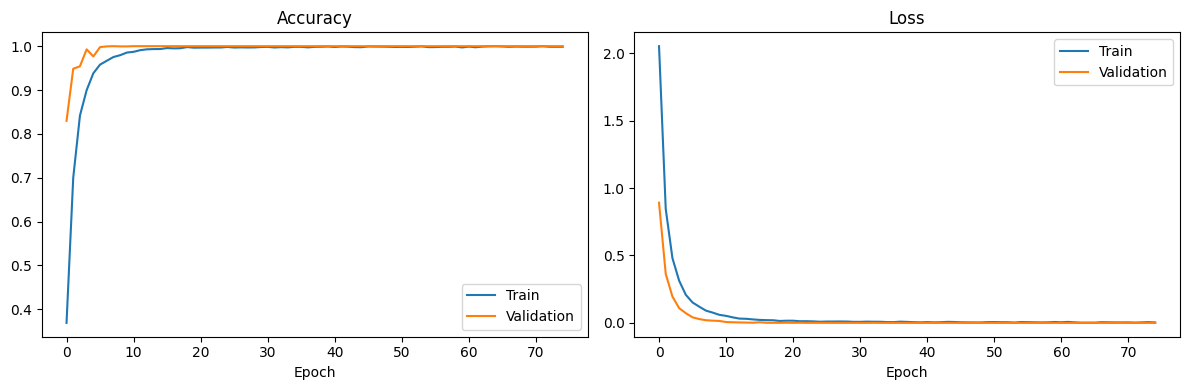

In [26]:
# Cell 9 — Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('../notebook/training_curves.png')
plt.show()

60/60 [==============================] - 0s 2ms/step


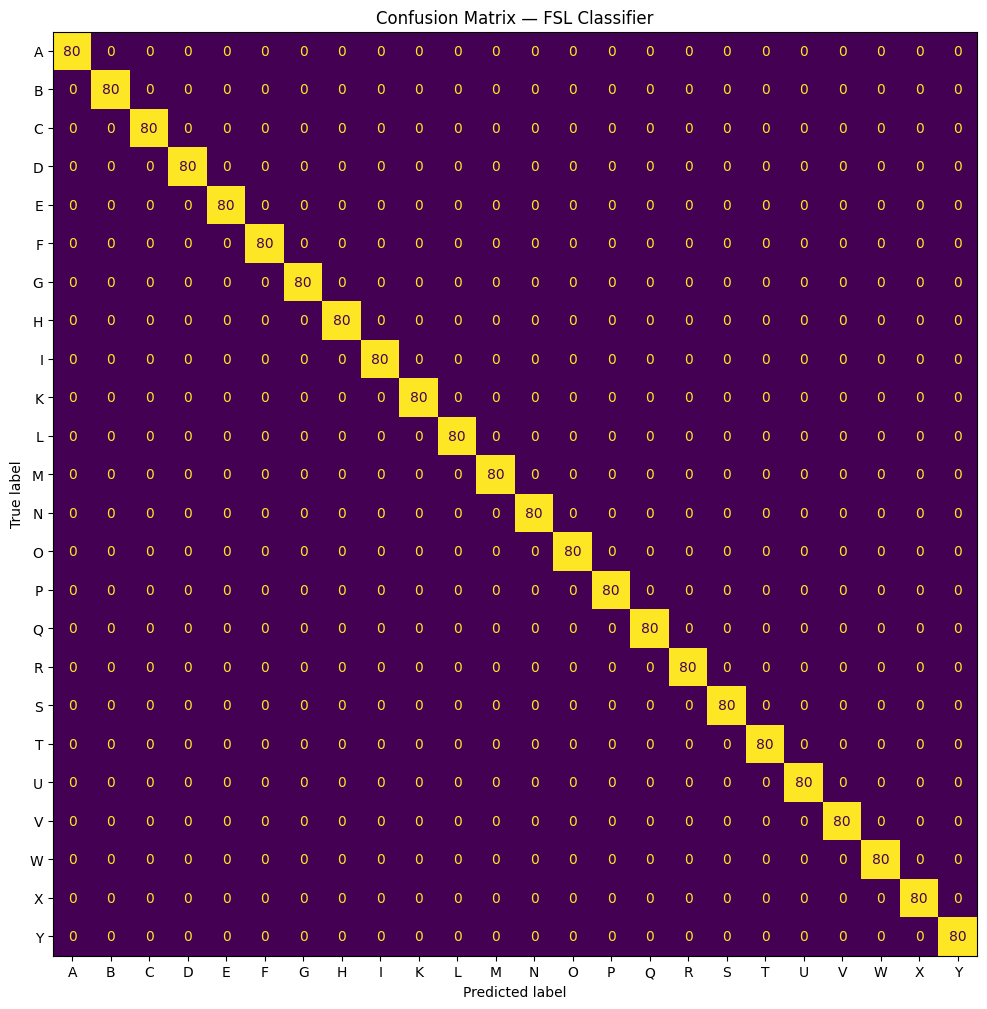

In [27]:
# Cell 10 — Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix — FSL Classifier')
plt.savefig('../notebook/confusion_matrix.png')
plt.show()

In [28]:
# Cell 11 — Save label map
import json

label_map = {i: label for i, label in enumerate(le.classes_)}
print(label_map)

with open('../label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)

print("label_map.json saved.")

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K', 10: 'L', 11: 'M', 12: 'N', 13: 'O', 14: 'P', 15: 'Q', 16: 'R', 17: 'S', 18: 'T', 19: 'U', 20: 'V', 21: 'W', 22: 'X', 23: 'Y'}
label_map.json saved.


In [29]:
# Cell 12 — Export to TF.js format (fixed weight names)
import json
import os

os.makedirs('../tfjs_model', exist_ok=True)

# Get model architecture
model_config = model.to_json()

# Get weights as flat binary
weights = model.get_weights()
weight_data = b''.join([w.astype('float32').tobytes() for w in weights])

# Build weight manifest with clean names (no :0 suffix)
weight_specs = []
for i, w in enumerate(weights):
    name = model.weights[i].name.replace(':0', '')
    weight_specs.append({
        "name": name,
        "shape": list(w.shape),
        "dtype": "float32"
    })

# Write weights binary
with open('../tfjs_model/group1-shard1of1.bin', 'wb') as f:
    f.write(weight_data)

# Write model.json
model_json = {
    "format": "layers-model",
    "generatedBy": "keras",
    "convertedBy": "manual",
    "modelTopology": json.loads(model_config),
    "weightsManifest": [{
        "paths": ["group1-shard1of1.bin"],
        "weights": weight_specs
    }]
}

with open('../tfjs_model/model.json', 'w') as f:
    json.dump(model_json, f)

print("Weight names written:")
for w in weight_specs:
    print(f"  {w['name']} — {w['shape']}")

Weight names written:
  dense_3/kernel — [63, 128]
  dense_3/bias — [128]
  dense_4/kernel — [128, 64]
  dense_4/bias — [64]
  dense_5/kernel — [64, 24]
  dense_5/bias — [24]


In [30]:
# Cell 13 — Verify model.json
import json

with open('../tfjs_model/model.json', 'r') as f:
    m = json.load(f)

print("Format:", m['format'])
print("Weight paths:", m['weightsManifest'][0]['paths'])
print("Number of weight tensors:", len(m['weightsManifest'][0]['weights']))
for w in m['weightsManifest'][0]['weights']:
    print(f"  {w['name']} — shape {w['shape']} — dtype {w['dtype']}")

Format: layers-model
Weight paths: ['group1-shard1of1.bin']
Number of weight tensors: 6
  dense_3/kernel — shape [63, 128] — dtype float32
  dense_3/bias — shape [128] — dtype float32
  dense_4/kernel — shape [128, 64] — dtype float32
  dense_4/bias — shape [64] — dtype float32
  dense_5/kernel — shape [64, 24] — dtype float32
  dense_5/bias — shape [24] — dtype float32
